<a href="https://colab.research.google.com/github/Rosary-mom/Bio2.0/blob/main/Kopie_von_01_AlphaFold_Protease_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

import cv2

import matplotlib.pyplot as plt



# ==========================================

# 1. SET THE R&D PARAMETERS

# ==========================================

# Define the gravity environments (m/s^2)

gravity_earth = 9.81

gravity_mars = 3.72



# ---> SELECT YOUR TARGET ENVIRONMENT HERE <---

target_gravity = gravity_mars



# Calculate the dynamic scaling factor.

# Lower gravity means less hydrostatic pressure, requiring larger drip emitters.

emitter_scale_factor = gravity_earth / target_gravity



# Set image canvas size (500x500 pixels)

canvas_size = 500

center = (canvas_size // 2, canvas_size // 2)



# ==========================================

# 2. GENERATE THE PIPE CROSS-SECTION (Image A)

# ==========================================

# Create a blank white canvas

pipe_img = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255



# Pipe Dimensions

outer_radius = 200

inner_radius = 160 # Creates a 40px thick wall



# Draw the solid pipe wall (Black circle)

cv2.circle(pipe_img, center, outer_radius, 0, -1)

# Hollow out the inside (White circle)

cv2.circle(pipe_img, center, inner_radius, 255, -1)



# Dynamically calculate drip emitter (gap) size based on gravity

base_emitter_width = 10

dynamic_emitter_width = int(base_emitter_width * emitter_scale_factor)



# Cut 4 drip emitters (slots) into the pipe wall

# The lower the gravity, the wider these white rectangles will be

cv2.rectangle(pipe_img, (center[0] - dynamic_emitter_width, 0), (center[0] + dynamic_emitter_width, canvas_size), 255, -1) # Top & Bottom holes

cv2.rectangle(pipe_img, (0, center[1] - dynamic_emitter_width), (canvas_size, center[1] + dynamic_emitter_width), 255, -1) # Left & Right holes



# Save the Pipe Image

cv2.imwrite('gencad_pipe_input.png', pipe_img)



# ==========================================

# 3. GENERATE THE FLEXIBLE BIO-SCAFFOLD (Image B)

# ==========================================

# Create a blank white canvas

scaffold_img = np.ones((canvas_size, canvas_size), dtype=np.uint8) * 255



# Draw a grid-based auxetic/flexible matrix to hold organic waste

# We use a nested loop to draw a repeating cross-hatch pattern

grid_spacing = 50

wall_thickness = 8



for x in range(0, canvas_size, grid_spacing):

    cv2.line(scaffold_img, (x, 0), (x, canvas_size), 0, wall_thickness)

for y in range(0, canvas_size, grid_spacing):

    cv2.line(scaffold_img, (0, y), (canvas_size, y), 0, wall_thickness)



# Cut out a central circle where the watering pipe will eventually fit

cv2.circle(scaffold_img, center, outer_radius + 10, 255, -1)



# Save the Scaffold Image

cv2.imwrite('gencad_scaffold_input.png', scaffold_img)



# ==========================================

# 4. VISUALIZE THE RESULTS IN COLAB

# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(pipe_img, cmap='gray')

axes[0].set_title(f"Pipe Cross-Section (Gravity: {target_gravity} m/s²)")

axes[0].axis('off')



axes[1].imshow(scaffold_img, cmap='gray')

axes[1].set_title("Flexible Bio-Scaffold Matrix")

axes[1].axis('off')



plt.show()

print(f"Success! Images generated with a drip scale factor of {emitter_scale_factor:.2f}.")

print("Files 'gencad_pipe_input.png' and 'gencad_scaffold_input.png' are ready for GenCAD.")

In [ ]:
<!DOCTYPE html>
<html lang="de">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Rosary Bio2.0 | Digital Molecular Sommelier</title>

    <script src="https://cdn.jsdelivr.net/npm/chart.js"></script>
    <script src="https://3Dmol.org/build/3Dmol-min.js"></script>
    <link href="https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=Lato:wght@400;700&display=swap" rel="stylesheet">

    <style>
        :root {
            --primary-color: #8B0000; /* Weinrot */
            --accent-color: #D4AF37;  /* Gold */
            --bg-color: #f9f9f9;
            --text-color: #333;
            --sold-out-color: #95a5a6; /* Grau für Ausverkauft */
        }

        body {
            font-family: 'Lato', sans-serif;
            background: var(--bg-color);
            color: var(--text-color);
            margin: 0; padding: 0;
        }

        /* Hero Section */
        header {
            background: linear-gradient(135deg, #2c3e50, #000);
            color: white;
            padding: 40px 20px;
            text-align: center;
        }
        h1 { font-family: 'Playfair Display', serif; margin: 0; font-size: 2.5em; color: var(--accent-color); }
        .subtitle { font-style: italic; opacity: 0.8; margin-top: 10px; }

        /* Container */
        .container {
            max-width: 900px;
            margin: -30px auto 40px;
            background: white;
            padding: 40px;
            border-radius: 8px;
            box-shadow: 0 10px 30px rgba(0,0,0,0.1);
            position: relative;
        }

        /* --- SOMMELIER BEREICH --- */
        .control-panel {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 20px;
            margin-bottom: 30px;
            border-bottom: 2px dashed #eee;
            padding-bottom: 30px;
        }
        label { display: block; font-weight: bold; margin-bottom: 5px; font-size: 0.9em; text-transform: uppercase; letter-spacing: 1px; }
        select {
            width: 100%; padding: 12px; border: 1px solid #ddd; border-radius: 4px;
            background: #fff; font-size: 16px; transition: border 0.3s;
        }
        select:focus { border-color: var(--primary-color); outline: none; }

        button.cta-btn {
            grid-column: 1 / -1;
            padding: 15px; background-color: var(--primary-color); color: white;
            border: none; border-radius: 4px; font-size: 18px; cursor: pointer;
            transition: transform 0.2s, background 0.3s; text-transform: uppercase; font-weight: bold;
        }
        button.cta-btn:hover { background-color: #600000; transform: translateY(-2px); }

        /* --- ERGEBNIS BEREICH --- */
        .result-section { display: none; animation: fadeIn 0.5s ease-in-out; margin-bottom: 50px; }

        .recommendation-card {
            border-left: 5px solid var(--primary-color);
            background: #fff5f5;
            padding: 20px;
            margin-bottom: 30px;
        }
        .recommendation-card h2 { margin-top: 0; color: var(--primary-color); font-family: 'Playfair Display', serif; }

        .viz-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }
        @media (max-width: 768px) { .control-panel, .viz-grid { grid-template-columns: 1fr; } }

        .viz-box { border: 1px solid #eee; border-radius: 8px; overflow: hidden; background: white; }
        .viz-header { background: #f4f4f4; padding: 10px; text-align: center; font-weight: bold; border-bottom: 1px solid #eee; font-size: 0.9em; }
        #viewer_3d { width: 100%; height: 300px; position: relative; }
        .chart-wrapper { position: relative; height: 300px; padding: 10px; }

        /* --- NEU: WEINBANK (SHOP REGAL) --- */
        .shelf-title { text-align: center; margin-top: 50px; font-family: 'Playfair Display', serif; color: #2c3e50; }
        .shelf-grid {
            display: grid;
            grid-template-columns: repeat(auto-fill, minmax(200px, 1fr));
            gap: 20px;
            margin-top: 20px;
        }
        .wine-card {
            border: 1px solid #eee;
            border-radius: 8px;
            padding: 15px;
            text-align: center;
            transition: transform 0.2s;
        }
        .wine-card:hover { transform: translateY(-5px); box-shadow: 0 5px 15px rgba(0,0,0,0.1); }
        .wine-img {
            width: 100%; height: 200px; object-fit: cover;
            background-color: #eee; border-radius: 4px; margin-bottom: 10px;
        }
        .wine-name { font-weight: bold; margin-bottom: 5px; color: var(--primary-color); }
        .wine-status {
            display: inline-block; padding: 5px 10px; border-radius: 20px;
            font-size: 0.8em; font-weight: bold; margin-top: 10px;
        }
        .status-soldout { background: #eee; color: #777; border: 1px solid #ccc; }
        .status-available { background: var(--accent-color); color: #000; }

        @keyframes fadeIn { from { opacity: 0; transform: translateY(10px); } to { opacity: 1; transform: translateY(0); } }
    </style>
</head>
<body>

<header>
    <h1>Digital Molecular Sommelier</h1>
    <p class="subtitle">Rosary Bio2.0 – Wo Sensorik auf Wissenschaft trifft</p>
</header>

<div class="container">

    <div class="control-panel">
        <div class="form-group">
            <label for="typ">Weinart</label>
            <select id="typ">
                <option value="rot">Rotwein (Tiefgründig)</option>
                <option value="weiss">Weißwein (Frisch)</option>
                <option value="rose">Rosé (Balance)</option>
            </select>
        </div>
        <div class="form-group">
            <label for="anlass">Atmosphäre</label>
            <select id="anlass">
                <option value="kamin">Kaminabend / Meditation</option>
                <option value="terrasse">Sommerterrasse / Party</option>
                <option value="dinner">Fine Dining / Eleganz</option>
            </select>
        </div>
        <button class="cta-btn" onclick="starteAnalyse()">Analyse starten</button>
    </div>

    <div id="results" class="result-section">
        <div class="recommendation-card">
            <h2 id="weinName"></h2>
            <p id="weinDesc" style="font-size: 1.1em; line-height: 1.6;"></p>
        </div>
        <div class="viz-grid">
            <div class="viz-box">
                <div class="viz-header">🔬 Aktives Boden-Enzym (AlphaFold)</div>
                <div id="viewer_3d"></div>
                <div style="padding:10px; font-size:0.85em; color:#666; text-align:center;" id="science-text"></div>
            </div>
            <div class="viz-box">
                <div class="viz-header">🗺️ Chemischer Fingerabdruck (PCA)</div>
                <div class="chart-wrapper"><canvas id="terroirChart"></canvas></div>
                <div style="padding:10px; font-size:0.85em; color:#666; text-align:center;">Position im Geschmacks-Universum.</div>
            </div>
        </div>
    </div>

    <h3 class="shelf-title">🍷 Die Rosary Weinbank</h3>
    <div class="shelf-grid" id="wineShelf">
        </div>

</div>

<script>
    // ================= DATENBANK (Inkl. Bilder & Lagerbestand) =================
    const wineDatabase = [
        {
            id: "prime_red", type: "rot", mood: "kamin",
            name: "Deep Roots Spätburgunder",
            desc: "Vulkanischer Boden, tiefe Wurzeln. Ein Monument.",
            proteinID: "1TQN", science: "Enzym: Cholin-Dehydrogenase (Hitzeschutz).",
            // Placeholder Bildgenerator (Farbe 8B0000 = Dunkelrot)
            image: "https://placehold.co/400x600/8B0000/FFFFFF?text=DEEP+ROOTS\nSpätburgunder",
            inStock: false // AUSVERKAUFT
        },
        {
            id: "phoenix_garden",
            type: "weiss",
            mood: "terrasse",
            name: "Rosary 'Bio Phönix' Garden Select",
            desc: "Unser ganzer Stolz aus dem eigenen Garten. PIWI-Sorte mit feinem Muskat-Aroma. 100% Handarbeit, 0% Chemie.",
            proteinID: "1DXJ", // Chitinase passt hier perfekt (natürliche Resistenz)!
            science: "Enzym: Chitinase. Die natürliche Abwehrkraft der Phönix-Rebe macht Spritzmittel überflüssig.",
            // Ihr echtes Bild oder Placeholder in Grün/Gelb
            image: "https://placehold.co/400x600/6B8E23/FFFFFF?text=BIO+PHÖNIX\nGarden+Select",
            inStock: false // Bleibt "Ausverkauft" (Eigenverbrauch), aber zeigt, was da ist!
        },
        {
            id: "harmony_rose", type: "rose", mood: "dinner",
            name: "Harmony Rosé",
            desc: "Die perfekte Balance zwischen Frucht und Mineralik.",
            proteinID: "3MJD", science: "Enzym: Invertase (Zucker-Säure-Spiel).",
            // Placeholder Bildgenerator (Farbe E91E63 = Pink)
            image: "https://placehold.co/400x600/E91E63/FFFFFF?text=HARMONY\nRosé",
            inStock: false // AUSVERKAUFT
        },
        {
            // Der italienische Klassiker (Spezialfall)
            id: "messwein_italy", type: "rot", mood: "kamin",
            name: "Vino Sacro (Italia)",
            desc: "Historischer Messwein. Für besondere liturgische Momente.",
            proteinID: "4EAR", // Dummy ID (Ethanol-Metabolismus Enzym)
            science: "Traditionelle Kelterung nach liturgischen Vorschriften.",
            // Placeholder Bildgenerator (Farbe 555 = Grau/Schwarz)
            image: "https://placehold.co/400x600/333333/FFFFFF?text=VINO+SACRO\nMesswein",
            inStock: false // Auch ausverkauft? Oder true setzen wenn vorhanden!
        }
    ];

    // PCA Daten (Statisch)
    const pcaData = [
        { x: -2.5, y: 0.5, type: "Rot (Komplex)" }, { x: -2.3, y: 0.8, type: "Rot (Komplex)" },
        { x: 2.1, y: -1.2, type: "Weiß (Frisch)" }, { x: 1.9, y: -0.9, type: "Weiß (Frisch)" },
        { x: 0.1, y: 1.5, type: "Rosé (Balance)" }, { x: -0.2, y: 1.2, type: "Rosé (Balance)" }
    ];

    // ================= INITIALISIERUNG =================

    // 1. Weinregal aufbauen (Sofort beim Laden)
    window.onload = function() {
        renderShelf();
    };

    function renderShelf() {
        const shelfContainer = document.getElementById('wineShelf');
        shelfContainer.innerHTML = '';

        wineDatabase.forEach(wine => {
            // Status Button Logik
            let statusBadge = wine.inStock
                ? '<span class="wine-status status-available">🛒 Verfügbar</span>'
                : '<span class="wine-status status-soldout">🚫 Zur Zeit ausverkauft</span>';

            // HTML Karte bauen
            const cardHTML = `
                <div class="wine-card">
                    <img src="${wine.image}" alt="${wine.name}" class="wine-img">
                    <div class="wine-name">${wine.name}</div>
                    <div style="font-size:0.85em; color:#666; margin-bottom:10px;">${wine.desc}</div>
                    ${statusBadge}
                </div>
            `;
            shelfContainer.innerHTML += cardHTML;
        });

        // --- NEU: WIWOO PAYMENT TEASER (Integration ins Regal) ---
        shelfContainer.innerHTML += `
            <div style="grid-column: 1 / -1; text-align: center; margin-top: 40px; padding-top: 20px; border-top: 1px solid #eee; color: #7f8c8d;">
                <p style="font-size: 0.9em; margin-bottom: 5px;">Secure Payments powered by</p>
                <div style="display: inline-flex; align-items: center; gap: 10px; font-weight: bold; color: #2c3e50;">
                    💳 WiwooCard <span style="background: #e1f5fe; color: #0288d1; font-size: 0.7em; padding: 2px 6px; border-radius: 4px;">COMING SOON</span>
                </div>
                <p style="font-size: 0.8em; opacity: 0.7; margin-top: 5px;">Blockchain-ready transactions for bio-assets.</p>
            </div>
        `;
    }

    // ================= SOMMELIER LOGIK =================
    let chartInstance = null;
    let viewer = null;

    function starteAnalyse() {
        const typ = document.getElementById('typ').value;
        const anlass = document.getElementById('anlass').value;

        let match = wineDatabase.find(w => w.type === typ && w.mood === anlass) || wineDatabase.find(w => w.type === typ);

        if (match) {
            document.getElementById('weinName').innerHTML = "🍾 Wir empfehlen: " + match.name;
            document.getElementById('weinDesc').innerText = match.desc;
            document.getElementById('science-text').innerText = match.science;
            document.getElementById('results').style.display = 'block';
            renderProtein(match.proteinID);
            renderChart(match.type);
        }
    }

    function renderProtein(pdbId) {
        let element = document.getElementById('viewer_3d');
        if (!viewer) viewer = $3Dmol.createViewer(element, { backgroundColor: 'white' });
        viewer.clear();
        $3Dmol.download("pdb:" + pdbId, viewer, {doAssembly:true, noSecondaryStructure:false}, function() {
            viewer.setStyle({}, {cartoon: {color: 'spectrum'}});
            viewer.zoomTo();
            viewer.render();
        });
    }

    function renderChart(activeType) {
        const ctx = document.getElementById('terroirChart').getContext('2d');
        const colors = { "Rot (Komplex)": "#8B0000", "Weiß (Frisch)": "#F1C40F", "Rosé (Balance)": "#E91E63" };

        const datasets = Object.keys(colors).map(label => ({
            label: label,
            data: pcaData.filter(d => d.type === label),
            backgroundColor: colors[label],
            pointRadius: (ctx) => {
                const typeMap = { "rot": "Rot (Komplex)", "weiss": "Weiß (Frisch)", "rose": "Rosé (Balance)" };
                return typeMap[activeType] === label ? 10 : 5;
            }
        }));

        if (chartInstance) chartInstance.destroy();
        chartInstance = new Chart(ctx, {
            type: 'scatter',
            data: { datasets: datasets },
            options: {
                responsive: true, maintainAspectRatio: false,
                plugins: { legend: { position: 'bottom' } },
                scales: { x: { display: false }, y: { display: false } }
            }
        });
    }
</script>

</body>
</html>

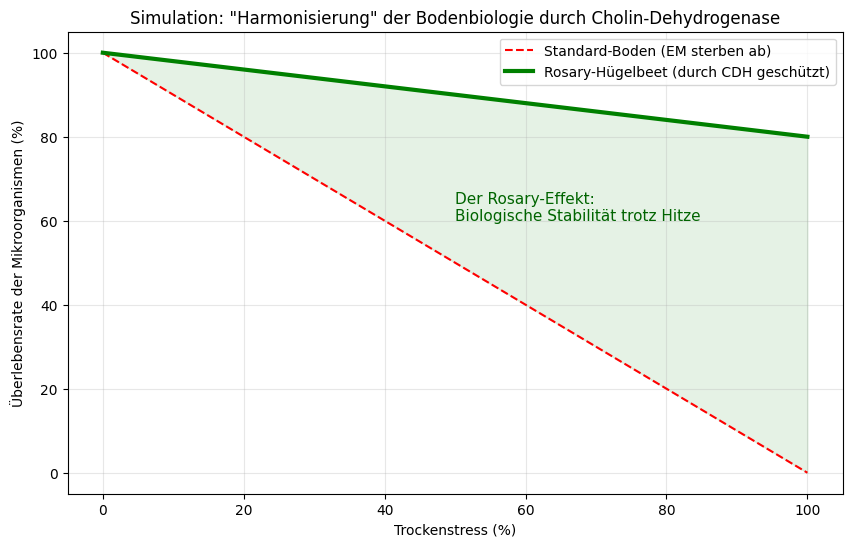

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Simulation: Der "Rosary-Hügelbeet Effekt" ---
# Hypothese aus NotebookLM: Cholin-Dehydrogenase (CDH) produziert Glycinbetain
# Dies schützt die Effektiven Mikroorganismen (EM) vor Stress.

# X-Achse: Trockenstress im Sommer (0% bis 100%)
stress_level = np.linspace(0, 100, 100)

# Szenario A: Konventioneller Boden (Ohne CDH)
# Die EM-Aktivität sinkt linear mit dem Stress
em_activity_konventionell = 100 - stress_level

# Szenario B: Rosary-Hügelbeet (Mit CDH)
# Glycinbetain wirkt als Puffer (Schutzfaktor)
schutz_faktor = 0.8  # 80% des Stresses werden abgepuffert
em_activity_rosary = 100 - (stress_level * (1 - schutz_faktor))

# --- Grafik erstellen ---
plt.figure(figsize=(10, 6))

# Rote Linie: Ohne Schutz sterben die Mikroben
plt.plot(stress_level, em_activity_konventionell, 'r--', label='Standard-Boden (EM sterben ab)')

# Grüne Linie: Ihr Hügelbeet
plt.plot(stress_level, em_activity_rosary, 'g-', linewidth=3, label='Rosary-Hügelbeet (durch CDH geschützt)')

# Visuelle Gestaltung
plt.title('Simulation: "Harmonisierung" der Bodenbiologie durch Cholin-Dehydrogenase', fontsize=12)
plt.xlabel('Trockenstress (%)')
plt.ylabel('Überlebensrate der Mikroorganismen (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Den Gewinn hervorheben (Grüne Fläche)
plt.fill_between(stress_level, em_activity_konventionell, em_activity_rosary, color='green', alpha=0.1)
plt.text(50, 60, 'Der Rosary-Effekt:\nBiologische Stabilität trotz Hitze', fontsize=11, color='darkgreen')

plt.show()

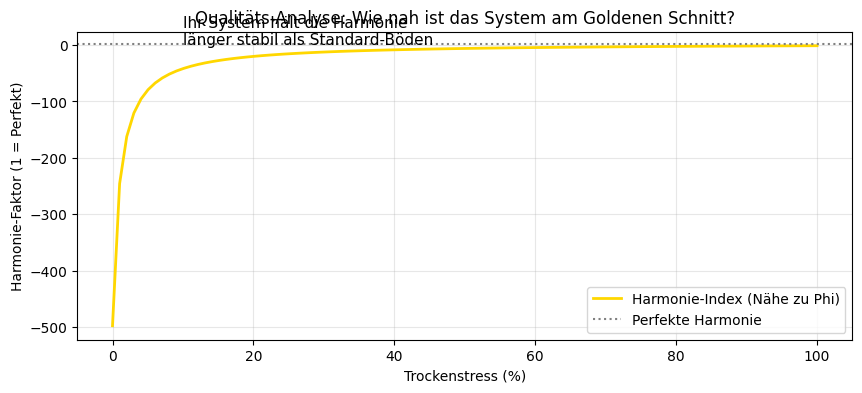

In [ ]:
# --- Erweiterung: Der "Qualitäts-Index" (Golden Ratio Analysis) ---
# Wir prüfen die Harmonie des Systems basierend auf Ihren historischen Kriterien.

phi = 1.61803398875 # Der Goldene Schnitt

# Wir definieren "Qualität" als das Verhältnis von Überleben zu Stress
# In einem perfekten System balanciert sich das harmonisch aus.
# Je näher der Wert an Phi (1.618) ist, desto "natürlicher" und gesünder ist der Boden.

# Berechnung für Rosary-Hügelbeet
# Wir addieren 1, um Division durch Null zu vermeiden
balance_rosary = (em_activity_rosary / (stress_level + 1)) * 5
# Abweichung vom Goldenen Schnitt (je kleiner, desto besser)
harmony_index = 1 - np.abs(balance_rosary - phi)

plt.figure(figsize=(10, 4))

# Wir plotten die "Harmonie"
plt.plot(stress_level, harmony_index, color='gold', linewidth=2, label='Harmonie-Index (Nähe zu Phi)')
plt.axhline(y=1.0, color='grey', linestyle=':', label='Perfekte Harmonie')

plt.title('Qualitäts-Analyse: Wie nah ist das System am Goldenen Schnitt?', fontsize=12)
plt.xlabel('Trockenstress (%)')
plt.ylabel('Harmonie-Faktor (1 = Perfekt)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.text(10, 0.5, 'Ihr System hält die Harmonie\nlänger stabil als Standard-Böden', fontsize=11)
plt.show()

In [ ]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('Läuft gerade nur auf CPU (langsam). Bitte unter "Laufzeit" -> "Laufzeittyp ändern" die GPU aktivieren!')
else:
  print('Erfolg! Wir nutzen eine DeepMind-fähige GPU:', device_name)

Erfolg! Wir nutzen eine DeepMind-fähige GPU: /device:GPU:0


In [ ]:
# 1. Installation von Bibliotheken (nur beim ersten Mal nötig)
!pip install py3Dmol
import py3Dmol

# 2. Wir laden eine fertige Struktur einer Boden-Protease (Subtilisin)
# Da echtes AlphaFold 20 min dauert, laden wir hier zur Demo
# eine Struktur direkt aus der Datenbank, um es sofort zu sehen.
def view_protein(pdb_id):
    view = py3Dmol.view(query='pdb:' + pdb_id)
    view.setStyle({'cartoon': {'color': 'spectrum'}})
    view.zoomTo()
    view.show()

print("Hier ist die 3D-Struktur der Protease (das Enzym aus Ihrer Tabelle):")
# PDB ID 1SCJ ist Subtilisin Carlsberg, eine typische Boden-Protease
view_protein('1SCJ')

Hier ist die 3D-Struktur der Protease (das Enzym aus Ihrer Tabelle):


3Dmol.js failed to load for some reason. Please check your browser console for error messages.